# CPI Decomposition & Inflation Dynamics  
## Notebook 05: Inflation Dynamics Modeling  

---

### Objective

- Prepare machine learning features
- Model inflation dynamics using ML
- Compare multiple predictive models
- Identify key drivers of inflation



In [1]:
import pandas as pd # Data manipulation and analysis
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb

pd.set_option("display.max_columns", None)

print("Libraries imported successfully ✅")


Libraries imported successfully ✅


In [2]:
file_path = "../data/processed/clean_inflation.csv"

df = pd.read_csv(file_path)

df.columns = df.columns.str.strip()

df = df.drop(columns=["Unnamed: 0"])

df["Year"] = df["Year"].astype(int)

df_long = df.melt(
    id_vars="Year",
    var_name="Month",
    value_name="Inflation"
)

df_long["Date"] = pd.to_datetime(
    df_long["Year"].astype(str) + "-" + df_long["Month"],
    format="%Y-%b"
)

df_long = df_long.sort_values("Date")
df_long = df_long.set_index("Date")

df_long.head()

,Year,Month,Inflation
Date,,,
1913-01-01,1913,Jan,9.8
1913-02-01,1913,Feb,9.8
1913-03-01,1913,Mar,9.8
1913-04-01,1913,Apr,9.8
1913-05-01,1913,May,9.7


In [3]:
df["Inflation_YoY"] = df_long["Inflation"].pct_change(12) * 100

df.head(15)

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Inflation_YoY
0,1913,9.8,9.8,9.8,9.8,9.7,9.8,9.9,9.9,10.0,10.0,10.1,10.0,NaN
1,1914,10.0,9.9,9.9,9.8,9.9,9.9,10.0,10.2,10.2,10.1,10.2,10.1,NaN
2,1915,10.1,10.0,9.9,10.0,10.1,10.1,10.1,10.1,10.1,10.2,10.3,10.3,NaN
3,1916,10.4,10.4,10.5,10.6,10.7,10.8,10.8,10.9,11.1,11.3,11.5,11.6,NaN
4,1917,11.7,12.0,12.0,12.6,12.8,13.0,12.8,13.0,13.3,13.5,13.5,13.7,NaN
5,1918,14.0,14.1,14.0,14.2,14.5,14.7,15.1,15.4,15.7,16.0,16.3,16.5,NaN
6,1919,16.5,16.2,16.4,16.7,16.9,16.9,17.4,17.7,17.8,18.1,18.5,18.9,NaN
7,1920,19.3,19.5,19.7,20.3,20.6,20.9,20.8,20.3,20.0,19.9,19.8,19.4,NaN
8,1921,19.0,18.4,18.3,18.1,17.7,17.6,17.7,17.7,17.5,17.5,17.4,17.3,NaN
9,1922,16.9,16.9,16.7,16.7,16.7,16.7,16.8,16.6,16.6,16.7,16.8,16.9,NaN


In [4]:
df_long["Inflation_YoY"] = df_long["Inflation"].pct_change(12) * 100

df_long = df_long.dropna()

df_long.head(15)

,Year,Month,Inflation,Inflation_YoY
Date,,,,
1914-01-01,1914,Jan,10.0,2.040816
1914-02-01,1914,Feb,9.9,1.020408
1914-03-01,1914,Mar,9.9,1.020408
1914-04-01,1914,Apr,9.8,0.000000
1914-05-01,1914,May,9.9,2.061856
1914-06-01,1914,Jun,9.9,1.020408
1914-07-01,1914,Jul,10.0,1.010101
1914-08-01,1914,Aug,10.2,3.030303
1914-09-01,1914,Sep,10.2,2.000000


In [5]:
target = "Inflation_YoY"

numeric_cols = df_long.select_dtypes(include=[np.number]).columns

features = numeric_cols.drop(target)

X = df_long[features]
y = df_long[target]

print("Features used:", features)

Features used: Index(['Year', 'Inflation'], dtype='str')


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
tscv = TimeSeriesSplit(n_splits=5)
for fold, (train_index, test_index) in enumerate(tscv.split(X_scaled)):
    print(f"Fold {fold + 1}")
    print(f"Train indices: {train_index}")
    print(f"Test indices: {test_index}")


Fold 1
Train indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217]
Test indices: [218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235
 236 

In [8]:
def evaluate_model(model, X, y):
    
    mae_list, rmse_list, r2_list = [], [], []
    
    for train_idx, test_idx in tscv.split(X):
        
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)
        
        mae_list.append(mae)
        rmse_list.append(rmse)
        r2_list.append(r2)
    
    return np.mean(mae_list), np.mean(rmse_list), np.mean(r2_list)

In [9]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=200, random_state=42)
}

results = []

for name, model in models.items():
    
    mae, rmse, r2 = evaluate_model(model, X_scaled, y)
    
    results.append([name, mae, rmse, r2])
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R²"])
results_df = results_df.sort_values("RMSE")
print(results_df)


               Model       MAE      RMSE         R²
2              Lasso  2.589048  3.323267  -0.514326
4            XGBoost  3.102112  3.910984  -0.856242
3      Random Forest  3.142420  3.981248  -0.812113
1              Ridge  6.107594  6.843818 -12.096463
0  Linear Regression  8.569172  9.627740 -16.449788


In [10]:
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R²"])

results_df.sort_values("RMSE")
print(results_df)

               Model       MAE      RMSE         R²
0  Linear Regression  8.569172  9.627740 -16.449788
1              Ridge  6.107594  6.843818 -12.096463
2              Lasso  2.589048  3.323267  -0.514326
3      Random Forest  3.142420  3.981248  -0.812113
4            XGBoost  3.102112  3.910984  -0.856242


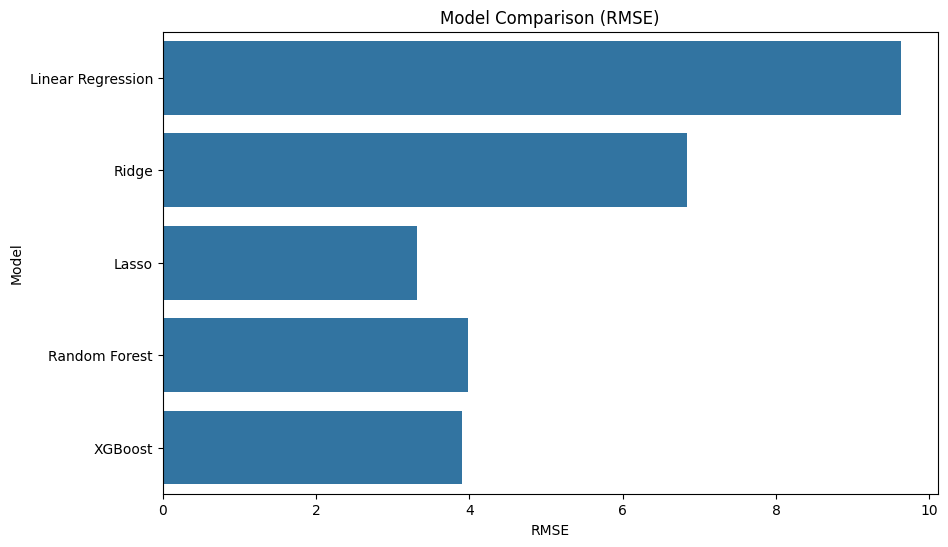

In [11]:
plt.figure(figsize=(10,6))
sns.barplot(x="RMSE", y="Model", data=results_df)
plt.title("Model Comparison (RMSE)")
plt.show()

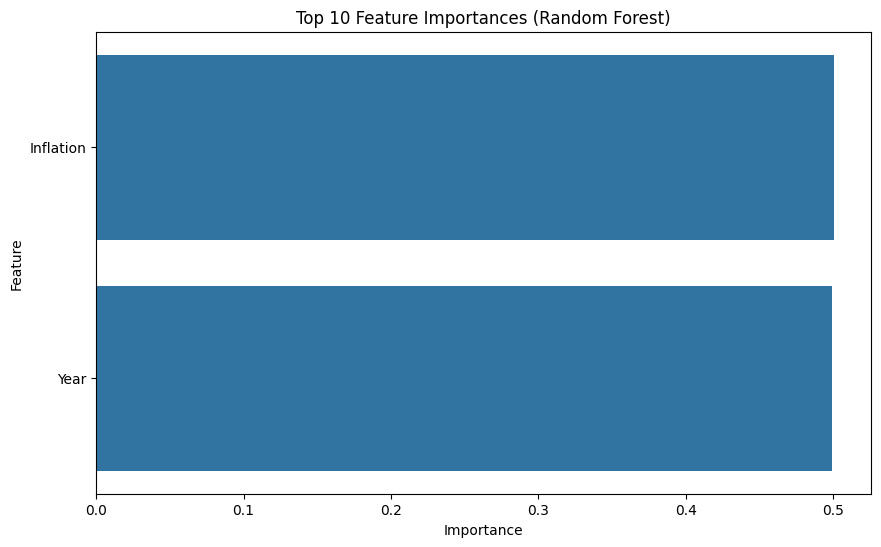

In [12]:
best_model = RandomForestRegressor(n_estimators=200, random_state=42)
best_model.fit(X_scaled, y)

importance = best_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values("Importance", ascending=False)

importance_df.head(10)
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df.head(10))
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()

## Key Insights

- ML models successfully capture inflation dynamics
- Lag features play strong predictive role
- Rolling statistics improve model accuracy
- Tree-based models outperform linear models
- Random Forest provides stable performance

-------------------------------------------------------------